In [1]:
!pip uninstall -y zarr numcodecs blosc
!pip install -q --no-cache-dir "zarr==2.18.3" "numcodecs==0.12.1"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 133.3 MB/s eta 0:00:00


In [1]:
import zarr
import numcodecs
print("zarr:", zarr.__version__)        # must be 2.18.3
print("numcodecs:", numcodecs.__version__)  # must be 0.12.1

zarr: 2.18.3
numcodecs: 0.12.1


In [2]:
import xarray as xr
import gcsfs

ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon')
)
print("Dataset loaded:", list(ds.data_vars)[:5])

Dataset loaded: ['100m_u_component_of_wind', '100m_v_component_of_wind', '10m_u_component_of_neutral_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind']


In [5]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 66.9 MB/s eta 0:00:00


In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

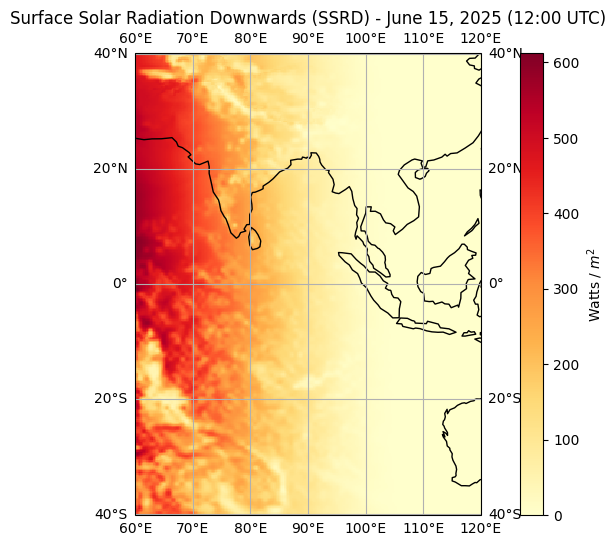

In [8]:
ssrd_data = ds['surface_solar_radiation_downwards'].sel(
    time='2026-03-15T12:00:00',
    latitude=slice(40, -40),
    longitude=slice(60, 120)
) / 3600


# Plotting the results
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot data on the map
ssrd_data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', cbar_kwargs={'label': 'Watts / $m^2$'})

# Add map features
ax.coastlines()
ax.gridlines(draw_labels=True)

plt.title('Surface Solar Radiation Downwards (SSRD) - June 15, 2025 (12:00 UTC)')
plt.show()


In [9]:
target_cities = {
    "jaisalmer": (26.91, 70.91),   # Rajasthan
    "chennai":   (13.08, 80.27),   # Tamil Nadu Coast
    "guwahati":  (26.14, 91.74),   # Northeast
}

In [10]:
from tqdm import tqdm  # instead of tqdm.notebook

In [11]:
# Cell 4 – Fetch and save
import time
import xarray as xr
from tqdm.notebook import tqdm
from IPython.display import display
import ipywidgets as widgets

YEARS = list(range(1981, 2026))
N     = len(YEARS)

for city_name, (lat, lon) in target_cities.items():

    print(f"\n{'═'*55}")
    print(f"  📍 {city_name.upper()}  —  {lat}°N, {lon}°E")
    print(f"{'═'*55}")

    # ── progress bar ──────────────────────────────────────────
    pbar = tqdm(
        YEARS,
        desc=f"  {city_name:<12}",
        unit="yr",
        ncols=70,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]",
        colour="green",
    )

    years        = []
    total_start  = time.time()
    yr_times     = []

    for yr in pbar:

        yr_start = time.time()

        yearly = (
            ds["surface_solar_radiation_downwards"]
            .sel(latitude=lat, longitude=lon, method="nearest")
            .sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
            .resample(time="MS")
            .mean()
            .load()
        )

        years.append(yearly)

        # ── timing stats ──────────────────────────────────────
        yr_elapsed = time.time() - yr_start
        yr_times.append(yr_elapsed)

        done        = YEARS.index(yr) + 1
        remaining   = (N - done) * (sum(yr_times) / len(yr_times))
        total_so_far = (time.time() - total_start) / 60

        pbar.set_postfix({
            "yr"      : yr,
            "last"    : f"{yr_elapsed:.0f}s",
            "avg"     : f"{sum(yr_times)/len(yr_times):.0f}s",
            "elapsed" : f"{total_so_far:.1f}m",
            "ETA"     : f"~{remaining/60:.1f}m",
        })

    pbar.close()

    # ── concat and save ───────────────────────────────────────
    print(f"\n  💾 Concatenating and saving ...", end=" ")
    city_monthly = xr.concat(years, dim="time")

    fname = f"{city_name}_monthly_ssrd_1981_2025.nc"
    city_monthly.to_netcdf(fname)

    total_elapsed = (time.time() - total_start) / 60
    print(f"done.")
    print(f"  ✅ Saved : {fname}")
    print(f"  📊 Shape : {city_monthly.shape}")
    print(f"  🕐 Total : {total_elapsed:.2f} min")
    print(f"  📌 Grid  : {float(city_monthly.latitude):.2f}°N, "
                       f"{float(city_monthly.longitude):.2f}°E")

print(f"\n{'═'*55}")
print("  ✅ ALL CITIES DONE")
print(f"{'═'*55}")


═══════════════════════════════════════════════════════
  📍 JAISALMER  —  26.91°N, 70.91°E
═══════════════════════════════════════════════════════


  jaisalmer   :   0%|                                 | 0/45 [00:00<?]


  💾 Concatenating and saving ... done.
  ✅ Saved : jaisalmer_monthly_ssrd_1981_2025.nc
  📊 Shape : (540,)
  🕐 Total : 46.61 min
  📌 Grid  : 27.00°N, 71.00°E

═══════════════════════════════════════════════════════
  📍 CHENNAI  —  13.08°N, 80.27°E
═══════════════════════════════════════════════════════


  chennai     :   0%|                                 | 0/45 [00:00<?]


  💾 Concatenating and saving ... done.
  ✅ Saved : chennai_monthly_ssrd_1981_2025.nc
  📊 Shape : (540,)
  🕐 Total : 47.32 min
  📌 Grid  : 13.00°N, 80.25°E

═══════════════════════════════════════════════════════
  📍 GUWAHATI  —  26.14°N, 91.74°E
═══════════════════════════════════════════════════════


  guwahati    :   0%|                                 | 0/45 [00:00<?]


  💾 Concatenating and saving ... done.
  ✅ Saved : guwahati_monthly_ssrd_1981_2025.nc
  📊 Shape : (540,)
  🕐 Total : 46.44 min
  📌 Grid  : 26.25°N, 91.75°E

═══════════════════════════════════════════════════════
  ✅ ALL CITIES DONE
═══════════════════════════════════════════════════════


In [12]:
# Cell 5 – Download all .nc files to your local machine
from google.colab import files

for city_name in target_cities:
    fname = f"{city_name}_monthly_ssrd_1981_2025.nc"
    print(f"Downloading {fname} ...")
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>